# Top-Selling Medicines Analysis

Identifies the highest-earning and highest-volume medicines, examines the 
relationship between revenue and quantity for top performers, and breaks down 
sales distribution by drug category.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

DATA_PATH = r"D:\7th sem\project\Medical_Sales_Analysis\data\pharmacy_sales.csv"
DATE_FORMAT = "%d-%m-%Y %H:%M"
TOP_N = 10

# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------

df = pd.read_csv(DATA_PATH)
df["DateTime"] = pd.to_datetime(df["DateTime"], format=DATE_FORMAT, errors="coerce")
df["Date"] = df["DateTime"].dt.date

df.head()

,SaleID,DateTime,DrugID,DrugName,DrugClass,Price,ExpDate,Quantity,TotalSales,Date
0,12005226,2023-04-01 09:04:00,D0051,Ciprofloxacin,Psychotropic,106,2024-03,6,636,2023-04-01
1,12005226,2023-04-01 09:04:00,D0051,Olmesartan,Analgesic,170,2023-10,2,340,2023-04-01
2,12005227,2023-04-01 09:05:00,D0049,Donepezil,Antiviral,184,2024-03,5,920,2023-04-01
3,12005227,2023-04-01 09:05:00,D0061,Fexofenadine,Hormonal,54,2023-05,6,324,2023-04-01
4,12005227,2023-04-01 09:05:00,D0034,Naproxen,Respiratory,50,2024-01,3,150,2023-04-01


## Top 10 Medicines by Revenue

Medicines ranked by total sales revenue across the observation period.

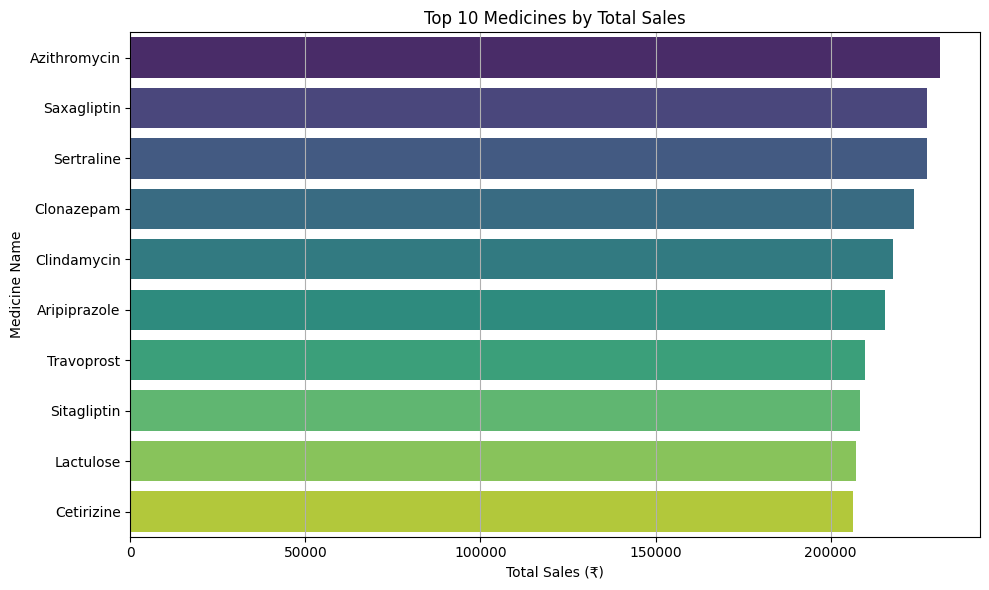

In [8]:
top_by_revenue = (
    df.groupby("DrugName")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_by_revenue,
    x="TotalSales",
    y="DrugName",
    hue="DrugName",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 Medicines by Total Sales")
ax.set_xlabel("Total Sales (₹)")
ax.set_ylabel("Medicine Name")
ax.grid(True, axis="x")
fig.tight_layout()
plt.show()

### Observed Trends

- Azithromycin, Saxagliptin, and Sertraline lead in revenue.
- Clonazepam and Clindamycin also contribute meaningfully through volume or unit price.

### Suggestions

- Monitor stock levels and expiry dates closely for top-earning medicines.
- Explore bulk purchasing or supplier negotiations for high-revenue drugs.

### Limitations

- Revenue-based ranking may overrepresent high-priced medicines sold infrequently.
- Does not reflect actual units sold.

## Top 10 Medicines by Quantity Sold

Medicines ranked by total units sold — reflects actual consumer demand independent of price.

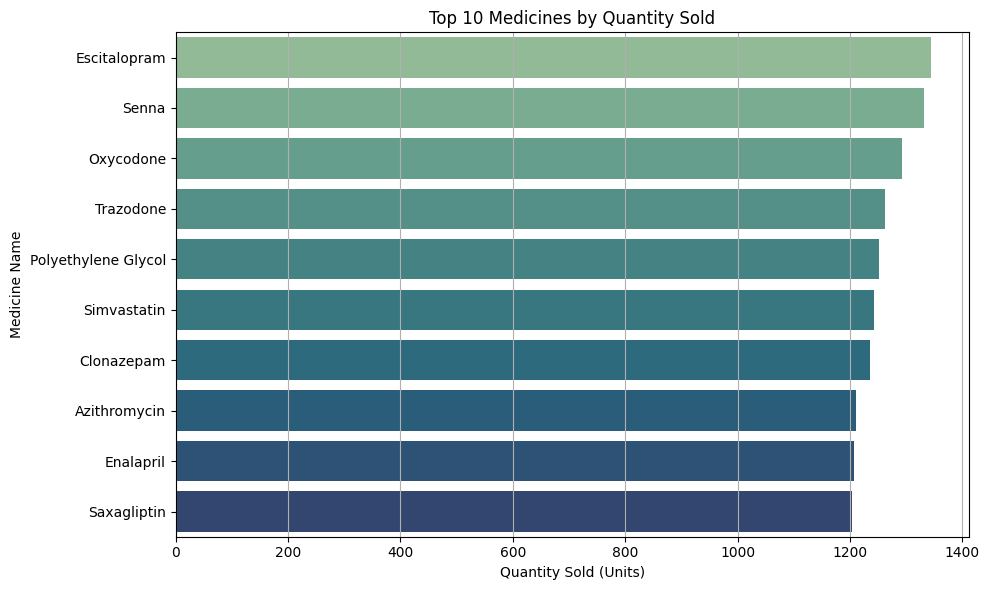

In [9]:
top_by_quantity = (
    df.groupby("DrugName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_by_quantity,
    x="Quantity",
    y="DrugName",
    hue="DrugName",
    palette="crest",
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 Medicines by Quantity Sold")
ax.set_xlabel("Quantity Sold (Units)")
ax.set_ylabel("Medicine Name")
ax.grid(True, axis="x")
fig.tight_layout()
plt.show()

### Observed Trends

- Escitalopram, Senna, and Oxycodone record the highest unit volumes.
- Azithromycin and Saxagliptin appear in both the revenue and quantity top 10 — high priority on both dimensions.

### Suggestions

- Maintain reliable stock for high-volume medicines to prevent shortages.
- Allocate shelf space proportionally to turnover velocity.

### Limitations

- Quantity rank does not reflect profitability.
- Low-cost medicines may dominate by units while contributing marginally to revenue.
- Expiry data is not considered — critical for high-volume bulk medicines.

## Revenue vs Quantity for Top 10 Earners

Scatter plot mapping total quantity sold against total revenue for the top 10 medicines by revenue.

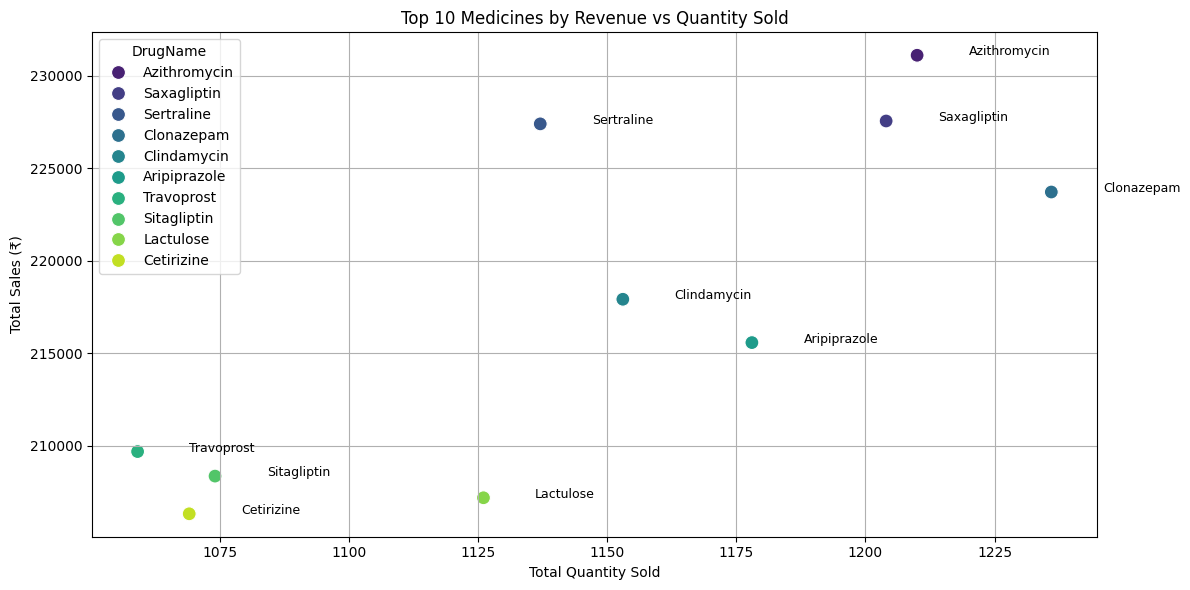

In [10]:
drug_summary = (
    df.groupby("DrugName")
    .agg(TotalSales=("TotalSales", "sum"), Quantity=("Quantity", "sum"))
    .reset_index()
)
top_10_revenue = drug_summary.sort_values("TotalSales", ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=top_10_revenue,
    x="Quantity",
    y="TotalSales",
    hue="DrugName",
    s=100,
    palette="viridis",
    ax=ax,
)

for _, row in top_10_revenue.iterrows():
    ax.text(row["Quantity"] + 10, row["TotalSales"], row["DrugName"], fontsize=9)

ax.set_title("Top 10 Medicines by Revenue vs Quantity Sold")
ax.set_xlabel("Total Quantity Sold")
ax.set_ylabel("Total Sales (₹)")
ax.grid(True)
fig.tight_layout()
plt.show()

### Observed Trends

- Positive correlation between quantity sold and revenue within the top 10.
- Azithromycin leads in revenue; Clonazepam leads in quantity among this group.
- Saxagliptin and Sertraline perform well on both dimensions.
- Travoprost, Cetirizine, and Sitagliptin rank low on both metrics.

### Suggestions

- Prioritise Clonazepam stock — high demand warrants bulk purchasing considerations.
- Promote Azithromycin and Saxagliptin — high revenue per unit sold.
- Review restocking frequency for low-performing medicines.

### Limitations

- Does not account for discounts, returns, or expiry losses.
- Top-10 focus may obscure emerging high-potential medicines outside this group.

## Sales Distribution by Drug Category — Revenue

Proportion of total revenue contributed by each drug class.

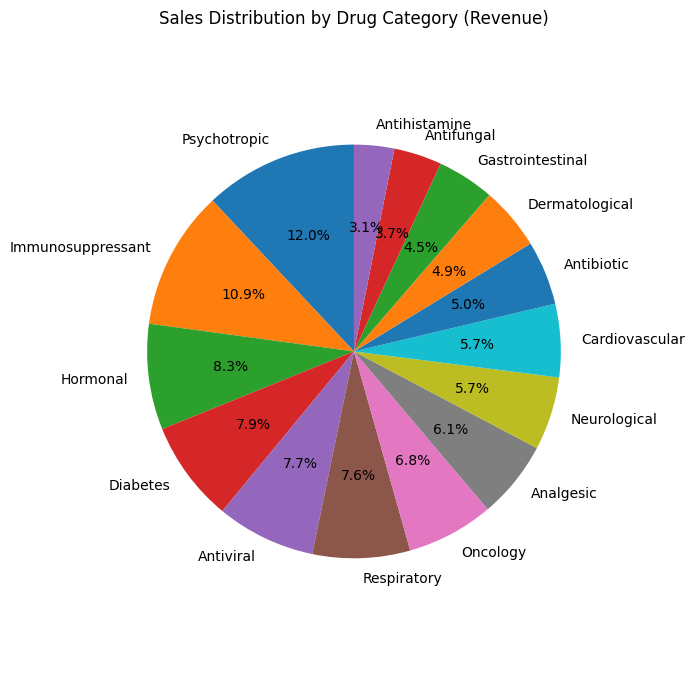

In [11]:
category_revenue = (
    df.groupby("DrugClass")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(category_revenue, labels=category_revenue.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Sales Distribution by Drug Category (Revenue)")
ax.axis("equal")
fig.tight_layout()
plt.show()

### Observed Trends

- Psychotropic and Immunosuppressant categories contribute the highest revenue share.
- Antihistamine, Antifungal, and Gastrointestinal categories contribute the least.

### Suggestions

- Prioritise stock and supplier negotiations for top-revenue categories.

### Limitations

- Revenue share does not reflect units sold or prescription frequency.
- Seasonal demand and regional health patterns are not captured.

## Sales Distribution by Drug Category — Quantity

Proportion of total units sold contributed by each drug class.

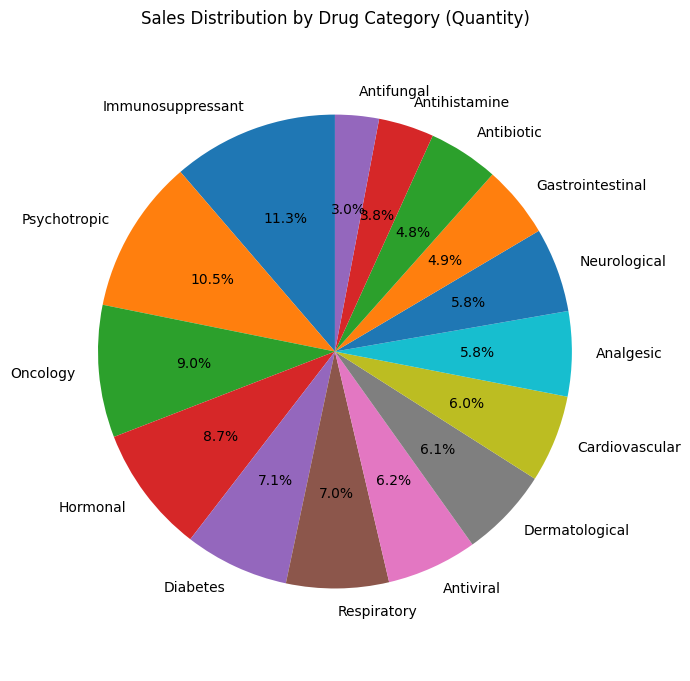

In [12]:
category_quantity = (
    df.groupby("DrugClass")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(category_quantity, labels=category_quantity.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Sales Distribution by Drug Category (Quantity)")
ax.axis("equal")
fig.tight_layout()
plt.show()

### Observed Trends

- Immunosuppressant and Psychotropic categories dominate by units sold.
- Antifungal, Antihistamine, and Antibiotic classes contribute the least.
- The distribution suggests long-term treatment categories are primary demand drivers.

### Suggestions

- Negotiate bulk deals with suppliers for high-volume categories to improve margins.
- Focus inventory on Immunosuppressant and Psychotropic categories to reduce stockouts.
- Consider educational or promotional strategies for underperforming categories.

### Limitations

- Quantity share does not reflect revenue or profitability.
- Seasonal demand and regional health factors are not included.